# Chargement des packages

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modèles de régression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Sauvegarde du modèle
import joblib

# Base de données Vente de Villas à Cocody

La base de données "Vente de Villas à Cocody" a été constituée à partir de données scrapées sur des annonces immobilières situées dans la commune de Cocody, à Abidjan. Elle regroupe des informations sur des villas mises en vente, incluant leurs caractéristiques physiques, leurs équipements et leur niveau de standing.

Cette base de données vise à capturer les éléments influençant le prix des biens immobiliers dans cette zone résidentielle prisée.

## Contenu de la base de données

La base de données contient les colonnes suivantes :

* `prix_fcfa` : prix de la villa en francs CFA
* `superficie_m2` : superficie du bien en mètres carrés
* `nombre_pieces` : nombre total de pièces
* `nombre_salles_bain` : nombre de salles de bain
* `jardin` : présence d’un jardin (0 = non, 1 = oui)
* `piscine` : présence d’une piscine (0 = non, 1 = oui)
* `parking` : présence d’un espace de stationnement (0 = non, 1 = oui)
* `terrasse` : présence d’une terrasse (0 = non, 1 = oui)
* `cuisineEquipee` : cuisine équipée (0 = non, 1 = oui)
* `securisee` : résidence sécurisée (0 = non, 1 = oui)
* `balcon` : présence d’un balcon (0 = non, 1 = oui)
* `cite` : localisation dans une cité (0 = non, 1 = oui)
* `meuble` : bien vendu meublé (0 = non, 1 = oui)
* `basse` : type de villa basse (0 = non, 1 = oui)
* `duplex` : villa de type duplex (0 = non, 1 = oui)
* `triplex` : villa de type triplex (0 = non, 1 = oui)

## Objectif de l’analyse

L’objectif de cette analyse est de construire un modèle de régression capable de prédire le prix d’une villa en fonction de ses caractéristiques physiques et de ses équipements.

La base de données sera divisée en ensembles d’apprentissage et de test afin d’entraîner le modèle et d’évaluer ses performances. Ce modèle pourra ensuite être utilisé pour estimer la valeur de biens immobiliers similaires sur le marché de Cocody.


# Importation et nettoyage des données

In [2]:
df = pd.read_csv("data_immo_villa.csv")

df.head()

,prix_fcfa,superficie_m2,nombre_pieces,nombre_salles_bain,jardin,piscine,parking,terrasse,cuisineEquipee,securisee,balcon,cite,meuble,basse,duplex,triplex
0,120000000.0,500.0,7.0,7.0,0,0,0,0,0,0,0,1,0,0,1,0
1,900000000.0,673.0,5.0,6.0,1,1,1,0,1,0,0,0,1,1,0,0
2,700000000.0,559.0,6.0,5.0,1,1,0,1,1,0,0,1,1,0,1,0
3,100000000.0,300.0,4.0,4.0,0,0,1,0,0,0,0,1,0,1,0,0
4,210000000.0,500.0,7.0,6.0,0,0,0,0,0,0,0,0,0,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4647 entries, 0 to 4646
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   prix_fcfa           4647 non-null   float64
 1   superficie_m2       4647 non-null   float64
 2   nombre_pieces       4647 non-null   float64
 3   nombre_salles_bain  4647 non-null   float64
 4   jardin              4647 non-null   int64  
 5   piscine             4647 non-null   int64  
 6   parking             4647 non-null   int64  
 7   terrasse            4647 non-null   int64  
 8   cuisineEquipee      4647 non-null   int64  
 9   securisee           4647 non-null   int64  
 10  balcon              4647 non-null   int64  
 11  cite                4647 non-null   int64  
 12  meuble              4647 non-null   int64  
 13  basse               4647 non-null   int64  
 14  duplex              4647 non-null   int64  
 15  triplex             4647 non-null   int64  
dtypes: flo

In [4]:
# Vérifier les valeurs manquantes
df.isnull().sum()

prix_fcfa             0
superficie_m2         0
nombre_pieces         0
nombre_salles_bain    0
jardin                0
piscine               0
parking               0
terrasse              0
cuisineEquipee        0
securisee             0
balcon                0
cite                  0
meuble                0
basse                 0
duplex                0
triplex               0
dtype: int64

In [5]:
# Remplissage simple (exemple)
df = df.fillna(0)

# Vérifier types
df.dtypes

prix_fcfa             float64
superficie_m2         float64
nombre_pieces         float64
nombre_salles_bain    float64
jardin                  int64
piscine                 int64
parking                 int64
terrasse                int64
cuisineEquipee          int64
securisee               int64
balcon                  int64
cite                    int64
meuble                  int64
basse                   int64
duplex                  int64
triplex                 int64
dtype: object

## Diviser la base de données en deux

# Modélisation Random Forest (Forêt Aléatoire)

### Préparation des données pour le modèle

In [6]:
X = df.drop("prix_fcfa", axis=1)  # variables explicatives
y = df["prix_fcfa"]               # variable cible

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modèle avec optimisation en utilisant les seuil pratique

Lorsque l'on utilise une forêt aléatoire, il est essentiel de faire des choix judicieux pour certains paramètres afin d'optimiser les performances du modèle. Deux paramètres importants à considérer sont :

- `max_features` : Il s'agit de la profondeur maximale de chaque arbre de décision dans la forêt. Une valeur appropriée pour `max_features` permet de contrôler la complexité du modèle et d'éviter le surajustement (overfitting).

**Une approche courante consiste à fixer `max_features` à la racine carrée du nombre de variables utilisées**. Cela permet de limiter la profondeur des arbres et de prévenir une croissance excessive, tout en maintenant un bon équilibre entre sous-apprentissage et surapprentissage.

- `n_estimators` : Il s'agit du nombre d'arbres de décision dans la forêt aléatoire. Un nombre suffisamment grand d'arbres permet d'améliorer les performances du modèle. Cependant, il est important de noter que l'augmentation de `n_estimators` entraîne également une augmentation du temps de calcul. Dans la pratique, on cherche à trouver un compromis entre les performances du modèle et le temps de calcul disponible. 


**Des études empiriques ont montré que l'ajout d'arbres après un certain point n'apporte que des gains marginaux en termes de performance**.

En ajustant ces paramètres de manière appropriée, on peut obtenir une forêt aléatoire bien équilibrée et performante pour la tâche donnée.


### Entrainement du modèle

In [8]:
# Hyperparamètre
max_features = int(np.sqrt(X.shape[1]))

model = RandomForestRegressor(
    n_estimators=200,
    max_features=max_features,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_features=3, n_estimators=200, random_state=42)

### Prédiction sur les bases train et test

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### Performances du modèle

**Explication des métriques**

**MAE** : erreur moyenne (en FCFA)

**RMSE** : pénalise les grosses erreurs

**R²** : qualité du modèle (1 = parfait)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train
print("TRAIN")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2 :", r2_score(y_train, y_train_pred))

print("\nTEST")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2 :", r2_score(y_test, y_test_pred))

TRAIN
MAE : 33758201.658509456
RMSE : 68540063.42528296
R2 : 0.9565496258779024

TEST
MAE : 72378126.1765062
RMSE : 139070187.3848581
R2 : 0.782355268455577


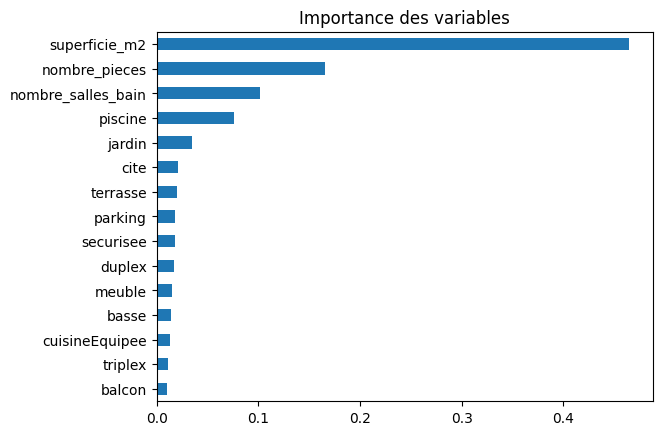

In [11]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')
plt.title("Importance des variables")
plt.show()


### Sauvegarde du modèle

In [12]:
joblib.dump(model, "model_prix_villa.pkl")

['model_prix_villa.pkl']

**Objectif de l’analyse (version propre)**

L’objectif de cette analyse est de construire un modèle de régression capable de prédire le prix d’une villa à partir de ses caractéristiques (superficie, équipements, standing, etc.).

La base de données est divisée en ensembles d’apprentissage et de test afin d’entraîner et d’évaluer les performances du modèle. Plusieurs algorithmes sont comparés afin de sélectionner le modèle le plus performant.